In [2]:
import os
import math
import time
import random
import csv
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu126
torchvision: 0.25.0+cu126


In [21]:

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False
DATA_DIR = "./data"

BATCH_SIZE = 64 if DEVICE.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2
EPOCHS = 4 if FAST_MODE else 12
IMG_SIZE = 224

Device: cuda


In [ ]:

STL10_MEAN = (0.4914, 0.4822, 0.4465)
STL10_STD  = (0.2023, 0.1994, 0.2010)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# class SubsetWithTransform(Subset):
#     """
#     Позволяет переопределить transform для конкретного сплита (Subset).
#     Это необходимо, чтобы применять аугментации только к train, 
#     а val/test оставлять с базовым трансформом.
#     """
#     def __init__(self, dataset, indices, transform=None):
#         super().__init__(dataset, indices)
#         self.transform = transform

#     def __getitem__(self, idx):
#         # Получаем оригинальное изображение (PIL) по индексу
#         img, target = self.dataset[self.indices[idx]]
#         # Применяем нужный трансформ
#         if self.transform:
#             img = self.transform(img)
#         return img, target
class SubsetWithTransform(Dataset):
    """
    Независимый Dataset, который применяет указанный transform к выборке по индексам.
    Гарантирует, что transform выполнится независимо от настроек исходного датасета.
    """
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        # Получаем оригинальные данные по индексу из исходного датасета
        img, target = self.dataset[self.indices[idx]]
        # Применяем трансформ, если он задан
        if self.transform is not None:
            img = self.transform(img)
        return img, target

    def __len__(self):
        return len(self.indices)

# --- Основная функция ---
def load_stl10(mode: str, data_dir: str = DATA_DIR, test_ratio: float = 0.2, val_ratio: float = 0.2, seed=RANDOM_STATE):
    """
    Загружает STL10 и возвращает сплиты (train, val, test) с трансформами в зависимости от mode.
    
    Args:
        mode (str): 'base' (только нормализация), 
                    'aug' (аугментации для train, нормализация для val/test), 
                    'resnet' (подготовка для pretrained ResNet).
    """
    
    transform_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    transform_aug = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop(96, scale=(0.7, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    transform_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

    # скачиваем датасет один раз, а затем применяем нужный transform через класс SubsetWithTransform
    ds_full = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=None)

    # 3. Разделение на сплиты (получаем индексы)
    total_size = len(ds_full)
    test_size = int(total_size * test_ratio)
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size - test_size

    gen = torch.Generator().manual_seed(seed)
    train_subset, val_subset, test_subset = random_split(
        ds_full, 
        [train_size, val_size, test_size], 
        generator=gen
    )

    if mode == 'base':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_base)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_base)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_base)

    elif mode == 'aug':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_aug)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_base)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_base)

    elif mode == 'resnet':
        ds_train = SubsetWithTransform(ds_full, train_subset.indices, transform=transform_resnet)
        ds_val = SubsetWithTransform(ds_full, val_subset.indices, transform=transform_resnet)
        ds_test = SubsetWithTransform(ds_full, test_subset.indices, transform=transform_resnet)

    else:
        raise ValueError(f"Unknown mode: {mode}. Choose from 'base', 'aug', 'resnet'.")

    return ds_train, ds_val, ds_test


ds_train, ds_val, ds_test = load_stl10(mode="aug")
class_names = ds_train.dataset.classes
print("Train full:", len(ds_train) + len(ds_val))
print("Test:", len(ds_test))
print("Classes:", class_names)
NUM_CLASSES = len(class_names)

Train full: 4000
Test: 1000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [18]:
def make_loaders(ds_train, ds_val, ds_test):

    train_loader = DataLoader(
        ds_train, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )
    val_loader = DataLoader(
        ds_val, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )
    test_loader = DataLoader(
        ds_test, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type != "cuda")
    )

    return train_loader, val_loader, test_loader

# sanity-check
train_loader, val_loader, test_loader = make_loaders(*load_stl10("base"))
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([128, 3, 96, 96]) torch.float32
y_batch: torch.Size([128]) torch.int64


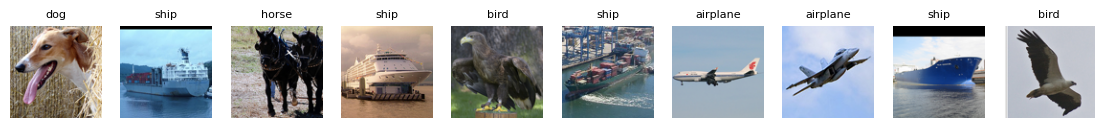

In [19]:
# визуализация картинок
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(96, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(48, 48, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(48 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))
     


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6912, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable params: 951146


In [8]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, train_loader: DataLoader, 
                   val_loader: DataLoader, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"experiment_id": exp_id, "history": hist, "best_val_acc": best_val_acc}


def save_results(res: dict, file="artifacts/runs.csv"):
    fieldnames = [
        "experiment_id", "task", "dataset", "seed", "model_summary", "optimizer", "lr",
        "epochs_trained", "best_val_accuracy", "test_accuracy", "precision", "recall", "mean_iou", "notes"
    ]

    file_exists = os.path.isfile(file)

    with open(file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()
        
        writer.writerow(res)


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 951146
Epoch 01/12 | train loss 1.9968, acc 0.257 | val loss 1.6782, acc 0.372 | 5.3s
Epoch 02/12 | train loss 1.5978, acc 0.425 | val loss 1.5789, acc 0.413 | 5.3s
Epoch 03/12 | train loss 1.3434, acc 0.519 | val loss 1.4172, acc 0.471 | 5.2s
Epoch 04/12 | train loss 1.1643, acc 0.577 | val loss 1.3610, acc 0.513 | 5.2s
Epoch 05/12 | train loss 0.9623, acc 0.656 | val loss 1.3374, acc 0.526 | 5.3s
Epoch 06/12 | train loss 0.7341, acc 0.746 | val loss 1.4604, acc 0.510 | 5.3s
Epoch 07/12 | train loss 0.5768, acc 0.800 | val loss 1.5478, acc 0.525 | 5.4s
Epoch 08/12 | train loss 0.4262, acc 0.857 | val loss 1.6625, acc 0.541 | 5.3s
Epoch 09/12 | train loss 0.2629, acc 0.918 | val loss 1.8517, acc 0.516 | 5.3s
Epoch 10/12 | train loss 0.1700, acc 0.950 | val loss 2.0903, acc 0.535 | 5.3s
Epoch 11/12 | train loss 0.1192, acc 0.966 | val loss 2.4809, acc 0.522 | 5.2s
Epoch 12/12 | train loss 0.0720, acc 0.984 | val loss

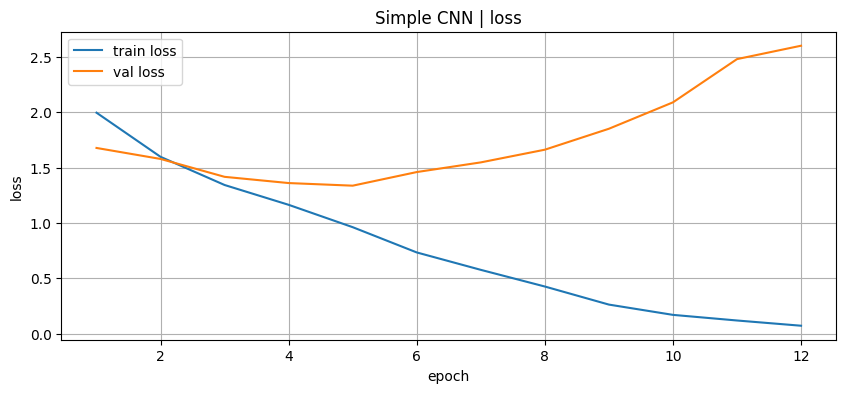

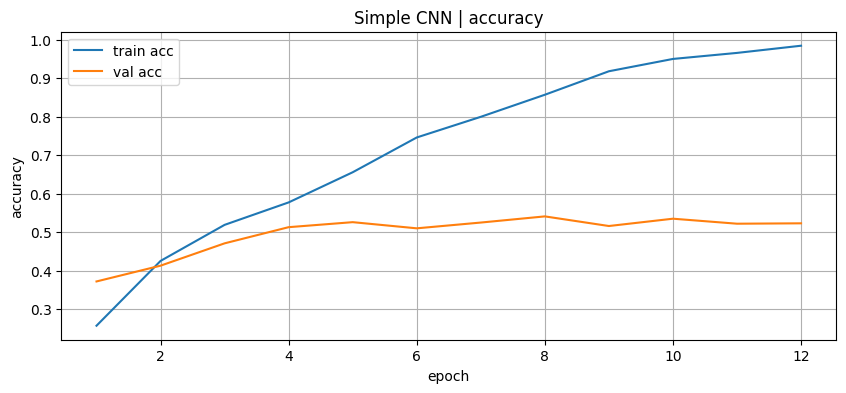

In [ ]:
experiment_id = "C1"
model_name= "Simple CNN"
lr = 1e-3
epochs = EPOCHS

train_loader, val_loader, test_loader = make_loaders(*load_stl10("base"))
res_cnn = run_experiment(experiment_id, SimpleCNN(NUM_CLASSES), train_loader=train_loader, val_loader=val_loader, lr=lr, epochs=EPOCHS)
plot_history(res_cnn["history"], title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "3 conv blocks, 2 classification layers",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": res_cnn["best_val_acc"],
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})


Experiment C2 | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 951146
Epoch 01/12 | train loss 2.0442, acc 0.231 | val loss 1.7982, acc 0.303 | 5.7s
Epoch 02/12 | train loss 1.7288, acc 0.359 | val loss 1.4952, acc 0.443 | 5.7s
Epoch 03/12 | train loss 1.5284, acc 0.441 | val loss 1.3907, acc 0.486 | 5.7s
Epoch 04/12 | train loss 1.4377, acc 0.483 | val loss 1.4170, acc 0.471 | 5.7s
Epoch 05/12 | train loss 1.3368, acc 0.507 | val loss 1.2264, acc 0.538 | 5.7s
Epoch 06/12 | train loss 1.2610, acc 0.551 | val loss 1.2523, acc 0.546 | 5.7s
Epoch 07/12 | train loss 1.2108, acc 0.572 | val loss 1.2991, acc 0.543 | 5.7s
Epoch 08/12 | train loss 1.1684, acc 0.586 | val loss 1.2084, acc 0.573 | 5.7s
Epoch 09/12 | train loss 1.0953, acc 0.615 | val loss 1.2253, acc 0.575 | 5.7s
Epoch 10/12 | train loss 1.0472, acc 0.625 | val loss 1.2002, acc 0.595 | 5.7s
Epoch 11/12 | train loss 0.9548, acc 0.663 | val loss 1.0886, acc 0.623 | 5.7s
Epoch 12/12 | train loss 0.9289, acc 0.672 | val loss

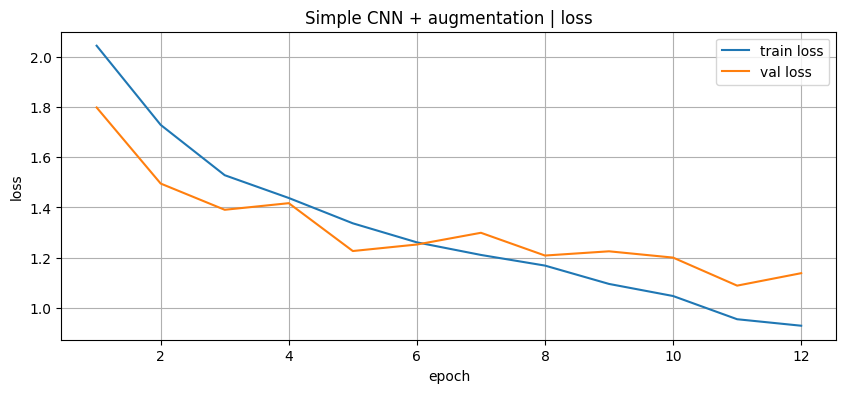

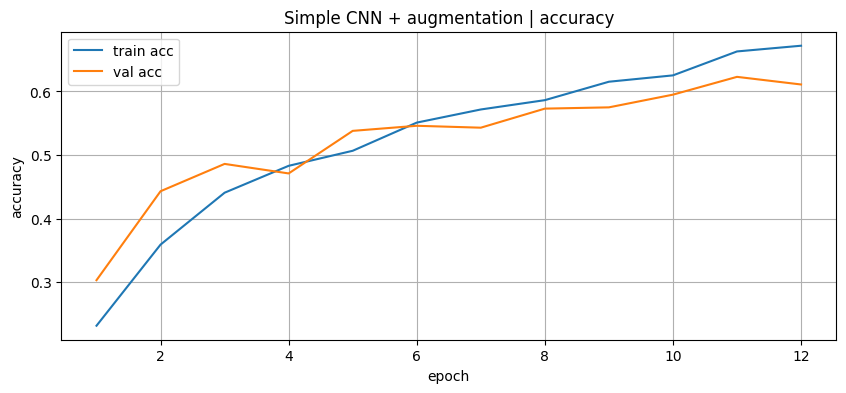

In [24]:
experiment_id = "C2"
model_name= "Simple CNN + augmentation"
lr = 1e-3
epochs = EPOCHS

train_loader, val_loader, test_loader = make_loaders(*load_stl10("aug"))
res_cnn = run_experiment(experiment_id, SimpleCNN(NUM_CLASSES), train_loader=train_loader, val_loader=val_loader, lr=lr, epochs=EPOCHS)
plot_history(res_cnn["history"], title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "3 conv blocks, 2 classification layers",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": res_cnn["best_val_acc"],
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})

In [ ]:

from torchvision.models import resnet18, ResNet18_Weights


def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [26]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/timofey/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/6 | train loss 1.2416, acc 0.688 | val loss 0.5531, acc 0.907 | 10.6s
Epoch 02/6 | train loss 0.4611, acc 0.913 | val loss 0.3534, acc 0.917 | 10.4s
Epoch 03/6 | train loss 0.3271, acc 0.928 | val loss 0.2737, acc 0.929 | 10.5s
Epoch 04/6 | train loss 0.2644, acc 0.938 | val loss 0.2332, acc 0.938 | 10.4s
Epoch 05/6 | train loss 0.2296, acc 0.946 | val loss 0.2056, acc 0.944 | 10.4s
Epoch 06/6 | train loss 0.2034, acc 0.952 | val loss 0.1904, acc 0.941 | 10.4s


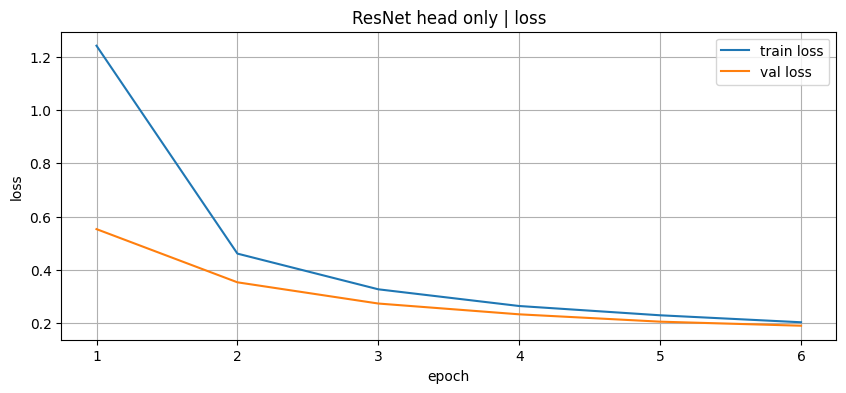

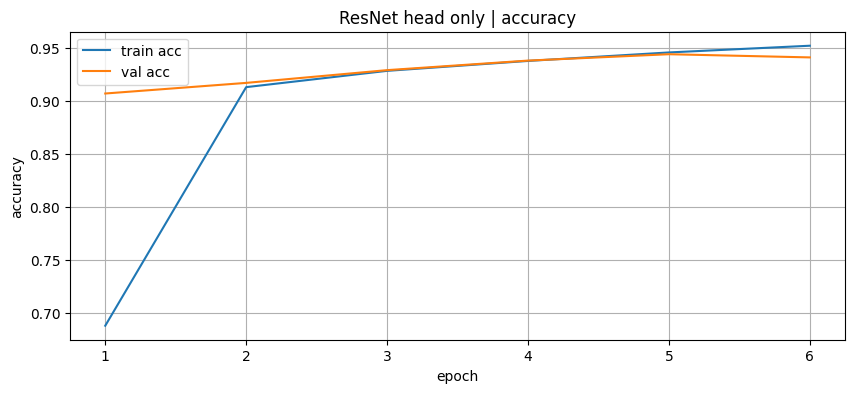

In [30]:
experiment_id = "C3"
model_name= "ResNet head only"
epochs = 6
lr = 1e-3

criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=lr)
train_loader, val_loader, test_loader = make_loaders(*load_stl10("resnet"))

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=epochs, verbose=True)
best_val_acc = max(hist_head["val_acc"])
plot_history(hist_head, title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18",
    "optimizer": "Adam", 
    "lr": lr,
    "epochs_trained": epochs,
    "best_val_accuracy": best_val_acc,
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/6 | train loss 0.0293, acc 0.993 | val loss 0.1172, acc 0.957 | 12.5s
Epoch 02/6 | train loss 0.0071, acc 1.000 | val loss 0.1142, acc 0.957 | 12.3s
Epoch 03/6 | train loss 0.0030, acc 1.000 | val loss 0.1593, acc 0.948 | 12.3s
Epoch 04/6 | train loss 0.0020, acc 1.000 | val loss 0.1233, acc 0.959 | 12.2s
Epoch 05/6 | train loss 0.0007, acc 1.000 | val loss 0.1092, acc 0.960 | 12.3s
Epoch 06/6 | train loss 0.0006, acc 1.000 | val loss 0.1073, acc 0.963 | 12.3s


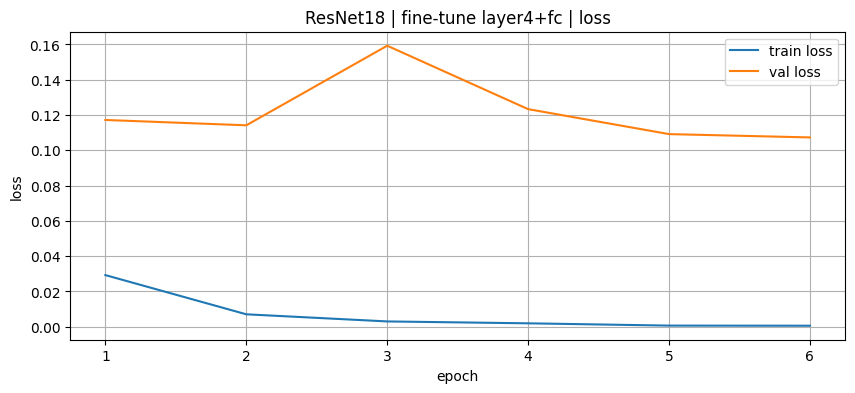

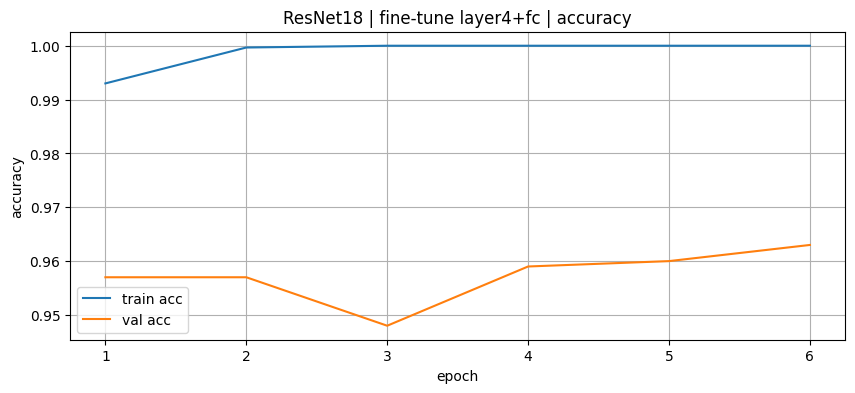

In [33]:
experiment_id = "C4"
model_name= "ResNet18 | fine-tune layer4+fc"
epochs = 6

# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=epochs, verbose=True)
best_val_acc = max(hist_head["val_acc"])
plot_history(hist_ft, title=model_name)
save_results({
    "experiment_id": experiment_id, 
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": "ResNet18 + fine-tune layer4+fc",
    "optimizer": "Adam", 
    "lr": "",
    "epochs_trained": epochs,
    "best_val_accuracy": best_val_acc,
    "test_accuracy": "", 
    "precision": "", 
    "recall": "", 
    "mean_iou": "", 
    "notes": model_name 
})
